<a href="https://colab.research.google.com/github/AshwinKumar710/MEDICAL-IMAGE-CLASSIFIER/blob/main/Medical_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import os

print(torch.cuda.is_available())  # should print True

True


In [2]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_45d0c597b742ecc456d95272b050882c'

In [3]:
!pip install -q kaggle
!kaggle datasets download -d navoneel/brain-mri-images-for-brain-tumor-detection
!unzip -q brain-mri-images-for-brain-tumor-detection.zip -d mri_data
!ls mri_data

Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
License(s): copyright-authors
100% 15.1M/15.1M [00:00<00:00, 115MB/s] 

brain_tumor_dataset  no  yes


In [4]:
!find mri_data -type d
!ls mri_data/brain_tumor_dataset/yes | head -5
!ls mri_data/brain_tumor_dataset/no | head -5

mri_data
mri_data/no
mri_data/yes
mri_data/brain_tumor_dataset
mri_data/brain_tumor_dataset/no
mri_data/brain_tumor_dataset/yes
Y100.JPG
Y101.jpg
Y102.jpg
Y103.jpg
Y104.jpg
10 no.jpg
11 no.jpg
12 no.jpg
13 no.jpg
14 no.jpg


In [6]:
import glob
from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms

class MRIDataset(Dataset):
    def __init__(self, root_dir, img_size=128, noise_factor=0.2):
        self.paths = glob.glob(os.path.join(root_dir, 'yes', '*')) + \
                     glob.glob(os.path.join(root_dir, 'no', '*'))
        self.noise_factor = noise_factor
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),               # scales to [0,1]
            transforms.Normalize((0.5,), (0.5,))  # scales to [-1,1]
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        clean = self.transform(img)
        noise = torch.randn_like(clean) * self.noise_factor
        noisy = torch.clamp(clean + noise, -1., 1.)
        return noisy, clean

In [7]:
from torch.utils.data import DataLoader

dataset = MRIDataset(root_dir='mri_data/brain_tumor_dataset', img_size=128)
print(f"Total images: {len(dataset)}")

dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# quick sanity check
noisy_batch, clean_batch = next(iter(dataloader))
print(noisy_batch.shape, clean_batch.shape)  # should be [16, 1, 128, 128]

Total images: 253
torch.Size([16, 1, 128, 128]) torch.Size([16, 1, 128, 128])


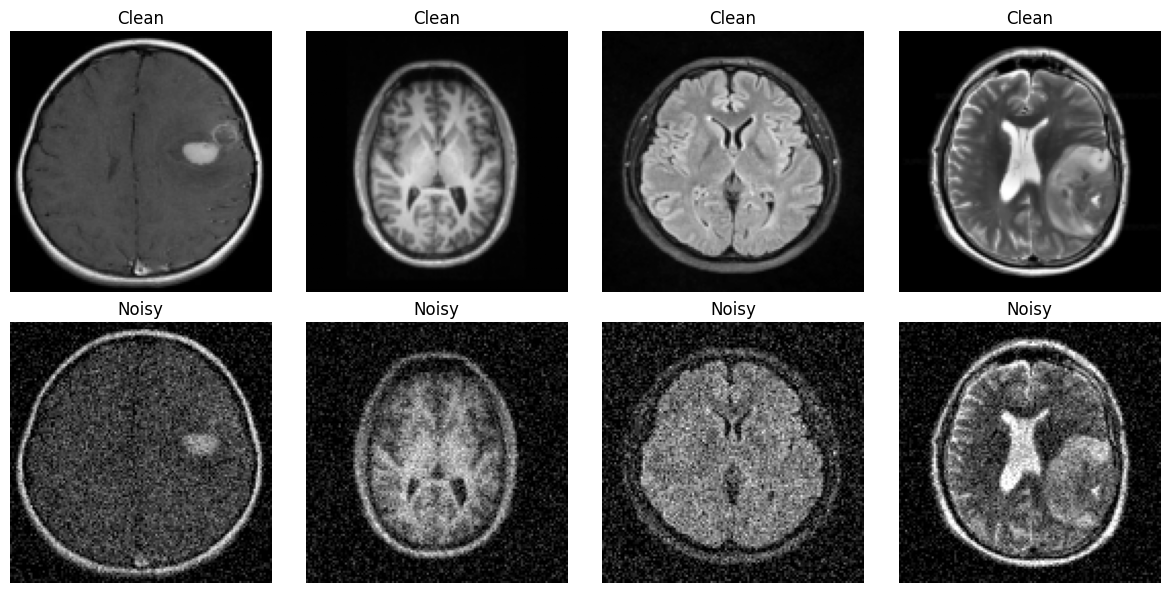

In [8]:
import matplotlib.pyplot as plt

def denorm(img):
    return img * 0.5 + 0.5  # undo normalization for display

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(denorm(clean_batch[i][0]), cmap='gray')
    axes[0, i].set_title("Clean")
    axes[0, i].axis('off')
    axes[1, i].imshow(denorm(noisy_batch[i][0]), cmap='gray')
    axes[1, i].set_title("Noisy")
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

In [10]:
import torch
import torch.nn as nn

class UNetDown(nn.Module):
    def __init__(self, in_ch, out_ch, normalize=True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 4, stride=2, padding=1)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class UNetUp(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip_input):
        x = self.model(x)
        return torch.cat((x, skip_input), dim=1)  # skip connection


class GeneratorUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        # Encoder
        self.down1 = UNetDown(in_channels, 64, normalize=False)  # 128->64
        self.down2 = UNetDown(64, 128)                           # 64->32
        self.down3 = UNetDown(128, 256)                          # 32->16
        self.down4 = UNetDown(256, 512)                          # 16->8
        self.down5 = UNetDown(512, 512)                          # 8->4
        self.down6 = UNetDown(512, 512, normalize=False)         # 4->2

        # Decoder
        self.up1 = UNetUp(512, 512, dropout=0.5)   # 2->4
        self.up2 = UNetUp(1024, 512, dropout=0.5)  # 4->8
        self.up3 = UNetUp(1024, 256)               # 8->16
        self.up4 = UNetUp(512, 128)                # 16->32
        self.up5 = UNetUp(256, 64)                 # 32->64

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, out_channels, 4, stride=2, padding=1),  # 64->128
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)

        u1 = self.up1(d6, d5)
        u2 = self.up2(u1, d4)
        u3 = self.up3(u2, d3)
        u4 = self.up4(u3, d2)
        u5 = self.up5(u4, d1)

        return self.final(u5)

In [11]:
gen = GeneratorUNet().cuda()
test_input = noisy_batch.cuda()
output = gen(test_input)
print(output.shape)  # should print torch.Size([16, 1, 128, 128])

torch.Size([16, 1, 128, 128])


In [12]:
class Discriminator(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()

        def block(in_ch, out_ch, normalize=True):
            layers = [nn.Conv2d(in_ch, out_ch, 4, stride=2, padding=1)]
            if normalize:
                layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.LeakyReLU(0.2))
            return layers

        self.model = nn.Sequential(
            *block(in_channels * 2, 64, normalize=False),  # input: noisy+clean concatenated
            *block(64, 128),
            *block(128, 256),
            *block(256, 512),
            nn.Conv2d(512, 1, 4, padding=1)  # output: patch grid of real/fake scores
        )

    def forward(self, img_A, img_B):
        # img_A = noisy (condition), img_B = clean or generated
        img_input = torch.cat((img_A, img_B), dim=1)
        return self.model(img_input)

In [13]:
disc = Discriminator().cuda()
test_output = disc(noisy_batch.cuda(), clean_batch.cuda())
print(test_output.shape)  # something like [16, 1, 7, 7] - a patch grid, not a single number

torch.Size([16, 1, 7, 7])


In [14]:
import torch.optim as optim

device = 'cuda'

generator = GeneratorUNet().to(device)
discriminator = Discriminator().to(device)

adversarial_loss = nn.MSELoss()   # LSGAN-style loss, more stable than BCE
pixelwise_loss = nn.L1Loss()

lambda_pixel = 100  # weight for L1 loss vs adversarial loss

optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# figure out patch grid size dynamically (from your Step 5 test, e.g. [16,1,7,7])
patch = (1, test_output.shape[2], test_output.shape[3])

In [15]:
num_epochs = 50

for epoch in range(num_epochs):
    for i, (noisy, clean) in enumerate(dataloader):
        noisy = noisy.to(device)
        clean = clean.to(device)

        valid = torch.ones((noisy.size(0), *patch), device=device)
        fake = torch.zeros((noisy.size(0), *patch), device=device)

        # ---------------------
        #  Train Generator
        # ---------------------
        optimizer_G.zero_grad()

        gen_output = generator(noisy)
        pred_fake = discriminator(noisy, gen_output)

        loss_GAN = adversarial_loss(pred_fake, valid)
        loss_pixel = pixelwise_loss(gen_output, clean)
        loss_G = loss_GAN + lambda_pixel * loss_pixel

        loss_G.backward()
        optimizer_G.step()

        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        pred_real = discriminator(noisy, clean)
        loss_real = adversarial_loss(pred_real, valid)

        pred_fake = discriminator(noisy, gen_output.detach())
        loss_fake = adversarial_loss(pred_fake, fake)

        loss_D = 0.5 * (loss_real + loss_fake)
        loss_D.backward()
        optimizer_D.step()

    print(f"Epoch [{epoch+1}/{num_epochs}]  D loss: {loss_D.item():.4f}  G loss: {loss_G.item():.4f}")

Epoch [1/50]  D loss: 0.2326  G loss: 17.4517
Epoch [2/50]  D loss: 0.2349  G loss: 12.6792
Epoch [3/50]  D loss: 0.2478  G loss: 11.5933
Epoch [4/50]  D loss: 0.2230  G loss: 11.0007
Epoch [5/50]  D loss: 0.1700  G loss: 12.4260
Epoch [6/50]  D loss: 0.1977  G loss: 12.3702
Epoch [7/50]  D loss: 0.2546  G loss: 9.5028
Epoch [8/50]  D loss: 0.2742  G loss: 11.4270
Epoch [9/50]  D loss: 0.2259  G loss: 9.0918
Epoch [10/50]  D loss: 0.1967  G loss: 8.8887
Epoch [11/50]  D loss: 0.2622  G loss: 7.5839
Epoch [12/50]  D loss: 0.2305  G loss: 8.1110
Epoch [13/50]  D loss: 0.2537  G loss: 7.4524
Epoch [14/50]  D loss: 0.2634  G loss: 7.5811
Epoch [15/50]  D loss: 0.1841  G loss: 8.4187
Epoch [16/50]  D loss: 0.4149  G loss: 8.6381
Epoch [17/50]  D loss: 0.2472  G loss: 8.9701
Epoch [18/50]  D loss: 0.2018  G loss: 7.6508
Epoch [19/50]  D loss: 0.1706  G loss: 7.5362
Epoch [20/50]  D loss: 0.2809  G loss: 7.0045
Epoch [21/50]  D loss: 0.0571  G loss: 8.7513
Epoch [22/50]  D loss: 0.4183  G los

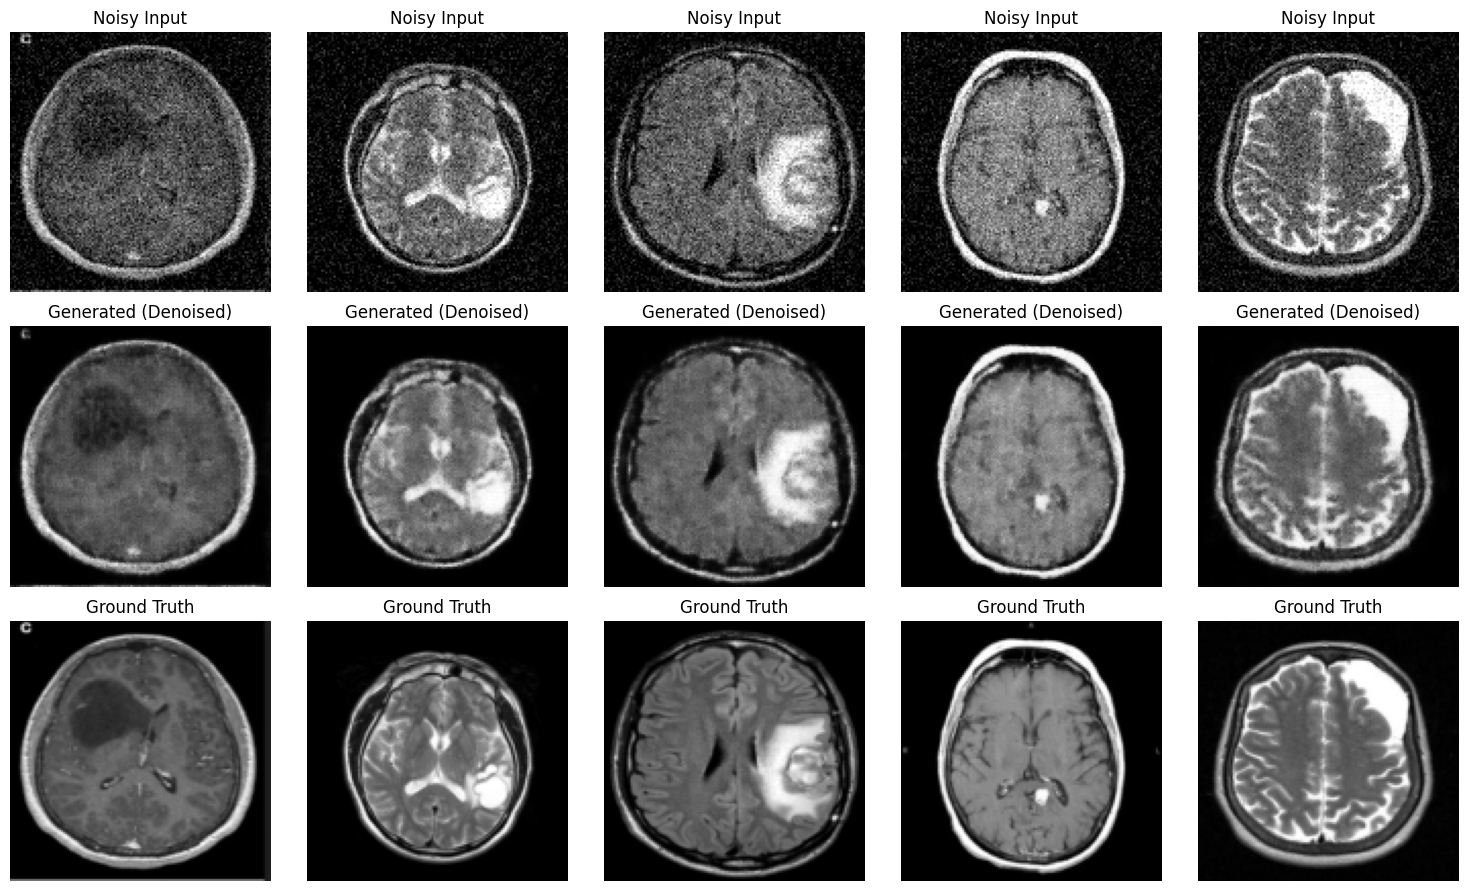

GeneratorUNet(
  (down1): UNetDown(
    (model): Sequential(
      (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.2)
    )
  )
  (down2): UNetDown(
    (model): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
  )
  (down3): UNetDown(
    (model): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
  )
  (down4): UNetDown(
    (model): Sequential(
      (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
  )
  (down5)

In [16]:
generator.eval()

with torch.no_grad():
    noisy_test, clean_test = next(iter(dataloader))
    noisy_test = noisy_test.to(device)
    generated = generator(noisy_test)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i in range(5):
    axes[0, i].imshow(denorm(noisy_test[i][0].cpu()), cmap='gray')
    axes[0, i].set_title("Noisy Input")
    axes[0, i].axis('off')

    axes[1, i].imshow(denorm(generated[i][0].cpu()), cmap='gray')
    axes[1, i].set_title("Generated (Denoised)")
    axes[1, i].axis('off')

    axes[2, i].imshow(denorm(clean_test[i][0].cpu()), cmap='gray')
    axes[2, i].set_title("Ground Truth")
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

generator.train()  # switch back to train mode in case you continue training

In [17]:
!pip install -q scikit-image

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import numpy as np

generator.eval()
psnr_scores = []
ssim_scores = []

with torch.no_grad():
    for noisy, clean in dataloader:
        noisy = noisy.to(device)
        generated = generator(noisy).cpu()

        for i in range(generated.size(0)):
            gen_img = denorm(generated[i][0]).numpy()
            clean_img = denorm(clean[i][0]).numpy()

            psnr_scores.append(psnr(clean_img, gen_img, data_range=1.0))
            ssim_scores.append(ssim(clean_img, gen_img, data_range=1.0))

print(f"Average PSNR: {np.mean(psnr_scores):.2f} dB")
print(f"Average SSIM: {np.mean(ssim_scores):.4f}")
generator.train()

Average PSNR: 27.39 dB
Average SSIM: 0.8089


GeneratorUNet(
  (down1): UNetDown(
    (model): Sequential(
      (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.2)
    )
  )
  (down2): UNetDown(
    (model): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
  )
  (down3): UNetDown(
    (model): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
  )
  (down4): UNetDown(
    (model): Sequential(
      (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
  )
  (down5)

In [18]:
torch.save(generator.state_dict(), 'mri_generator.pth')
from google.colab import files
files.download('mri_generator.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>